# Two-Population SEIR: Structure, Coupling, and Effective Reproduction

## Overview

This notebook introduces explicit population structure with two groups: `general` and `cluster`.

We keep this notebook free of interventions. The goal is to show how static contact structure alone changes epidemic behavior.

Key questions:
- How do trajectories differ between populations with different within-group transmission?
- How much do bridge links matter, even without policy changes?
- How can we interpret group-level effective reproduction via a next-generation matrix?

## Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from epi_structure import (
    SimulationParameters,
    StructuredEpidemicModel,
    get_scenario,
    show_params,
    summarize_two_population_runs,
    trajectory_to_df,
)

plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

print('Imports and helpers ready.')

Imports and helpers ready.


## Baseline Structured Scenario

In [2]:
scenario = get_scenario('baseline')

# Extend horizon to observe full coupling dynamics while preserving dt/stride
sim = SimulationParameters(
    time_step=scenario.simulation.time_step,
    duration=120.0,
    output_stride=scenario.simulation.output_stride,
)

names = scenario.population_names
C = np.array(scenario.contact_matrix, dtype=float)

show_params(
    'Simulation Settings',
    populations=names,
    time_step=sim.time_step,
    duration_days=sim.duration,
    output_stride_steps=sim.output_stride,
)

print('\nContact matrix C (to_group row, from_group column):')
print(pd.DataFrame(C, index=names, columns=names).round(8))

for pop in scenario.populations:
    d = pop.disease
    show_params(
        f"Population: {pop.name}",
        size=pop.size,
        initial_s=pop.initial_susceptible,
        initial_e=pop.initial_exposed,
        initial_i=pop.initial_infected,
        infectious_period=d.infectious_period,
        latent_period=d.latent_period,
    )


Simulation Settings:
  populations              = ['general', 'cluster']
  time_step                = 0.100000
  duration_days            = 120.000000
  output_stride_steps      = 10

Contact matrix C (to_group row, from_group column):
         general  cluster
general  0.00004  0.00018
cluster  0.00001  0.00050

Population: general:
  size                     = 10000
  initial_s                = 9999
  initial_e                = 0
  initial_i                = 1
  infectious_period        = 6.000000
  latent_period            = 2.500000

Population: cluster:
  size                     = 500
  initial_s                = 496
  initial_e                = 0
  initial_i                = 4
  infectious_period        = 6.000000
  latent_period            = 2.500000


## Run Two-Population Baseline (No Interventions)

In [3]:
model = StructuredEpidemicModel(
    populations=scenario.populations,
    contact_matrix=scenario.contact_matrix,
    simulation=sim,
    intervention_plan=None,
)

trajectory = model.simulate()
df = trajectory_to_df(trajectory)

# Conservation check per population
df['sum_compartments'] = df['S'] + df['E'] + df['I'] + df['R']
dev = (df['sum_compartments'] - df['N']).abs().max()
print(f"Population conservation max deviation: {dev:.6f}")

df_summary = summarize_two_population_runs(
    ['baseline'],
    {'baseline': trajectory},
    general_name=names[0],
    cluster_name=names[1],
    general_size=float(scenario.populations[0].size),
    cluster_size=float(scenario.populations[1].size),
)
print('\nBaseline summary:')
print(df_summary.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

Population conservation max deviation: 0.000000

Baseline summary:
scenario  general_peak_I  general_peak_t  general_end_I  general_peak_pct  cluster_peak_I  cluster_peak_t  cluster_end_I  cluster_peak_pct
baseline         1896.85           40.00           0.74             18.97           74.07           43.00           0.10             14.81


## Population Trajectories

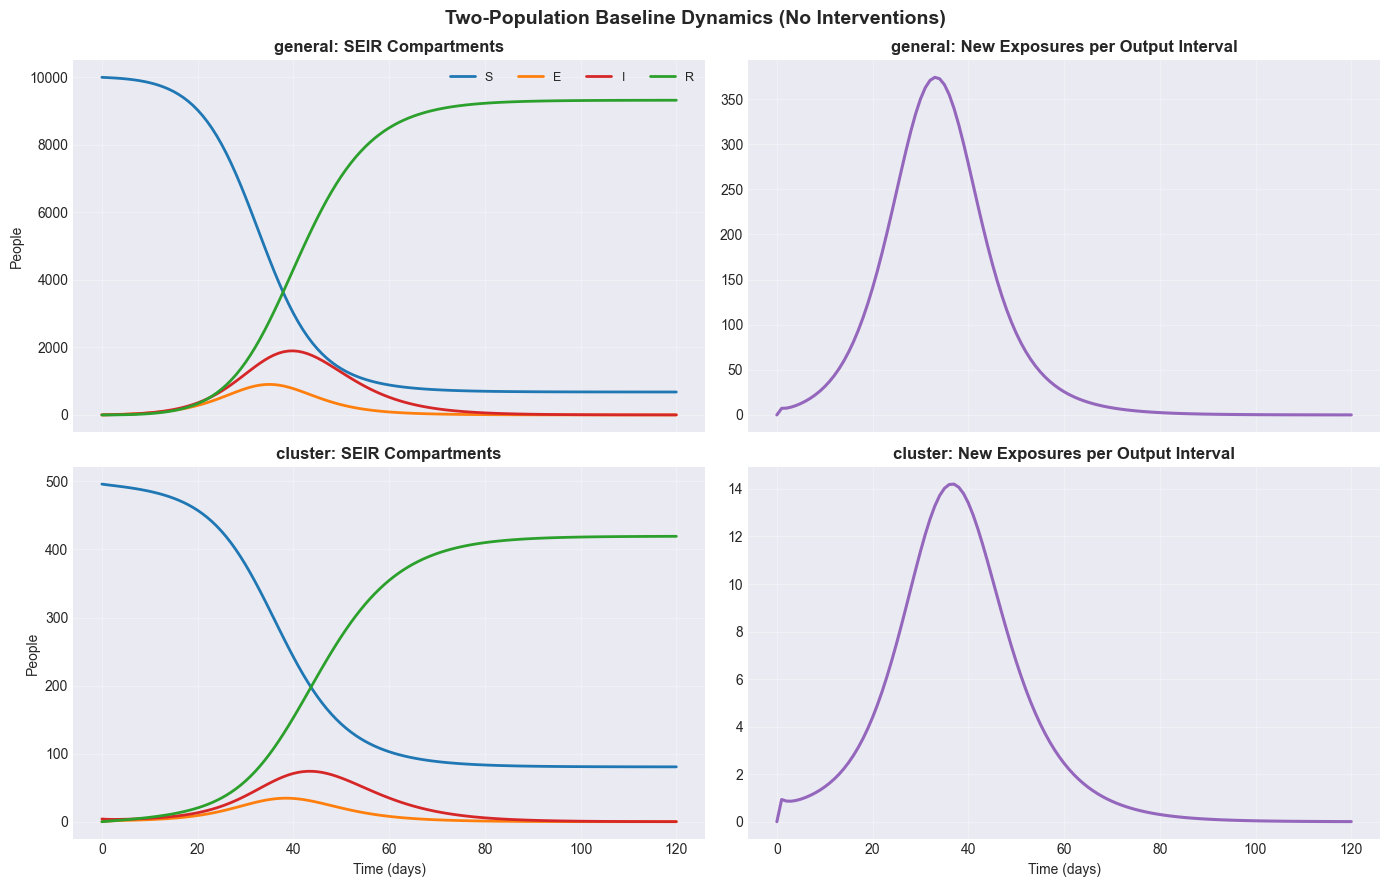

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

for row, p in enumerate(names):
    d = df[df['population'] == p]

    ax = axes[row, 0]
    ax.plot(d['time'], d['S'], label='S', linewidth=2, color='#1f77b4')
    ax.plot(d['time'], d['E'], label='E', linewidth=2, color='#ff7f0e')
    ax.plot(d['time'], d['I'], label='I', linewidth=2, color='#d62728')
    ax.plot(d['time'], d['R'], label='R', linewidth=2, color='#2ca02c')
    ax.set_title(f"{p}: SEIR Compartments", fontsize=12, fontweight='bold')
    ax.set_ylabel('People')
    ax.grid(True, alpha=0.3)
    if row == 0:
        ax.legend(ncol=4, fontsize=9, loc='upper right')

    ax = axes[row, 1]
    ax.plot(d['time'], d['new_exposed_interval'], linewidth=2.2, color='#9467bd')
    ax.set_title(f"{p}: New Exposures per Output Interval", fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

axes[1, 0].set_xlabel('Time (days)')
axes[1, 1].set_xlabel('Time (days)')
fig.suptitle('Two-Population Baseline Dynamics (No Interventions)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Combined System View

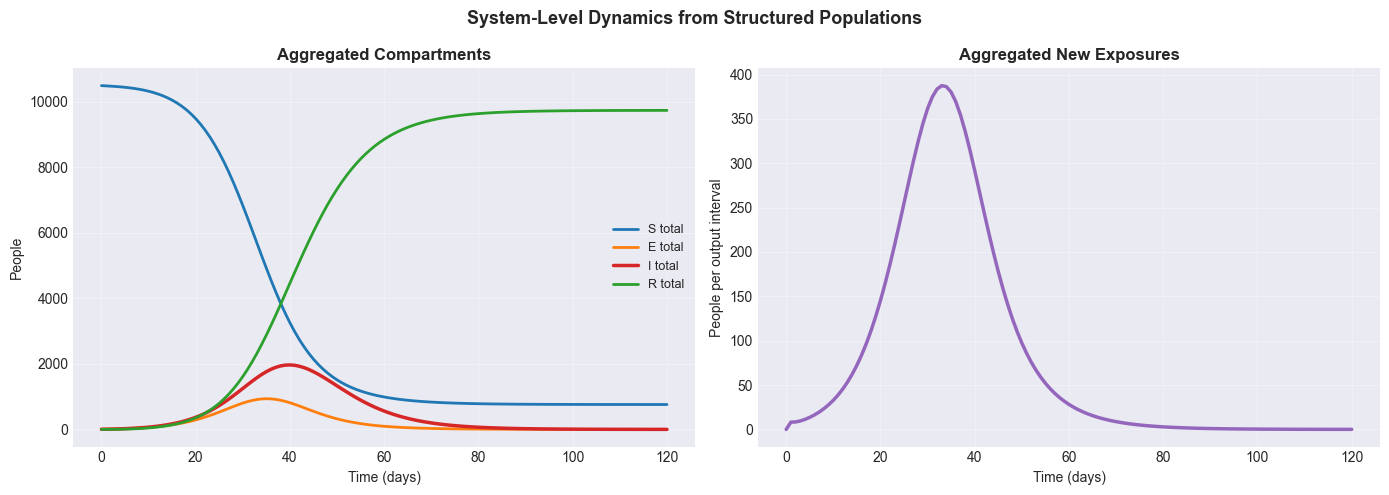

In [5]:
agg = df.groupby('time', as_index=False)[['S', 'E', 'I', 'R', 'new_exposed_interval']].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(agg['time'], agg['S'], label='S total', linewidth=2, color='#1f77b4')
ax.plot(agg['time'], agg['E'], label='E total', linewidth=2, color='#ff7f0e')
ax.plot(agg['time'], agg['I'], label='I total', linewidth=2.5, color='#d62728')
ax.plot(agg['time'], agg['R'], label='R total', linewidth=2, color='#2ca02c')
ax.set_xlabel('Time (days)')
ax.set_ylabel('People')
ax.set_title('Aggregated Compartments', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(agg['time'], agg['new_exposed_interval'], linewidth=2.5, color='#9467bd')
ax.set_xlabel('Time (days)')
ax.set_ylabel('People per output interval')
ax.set_title('Aggregated New Exposures', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

fig.suptitle('System-Level Dynamics from Structured Populations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Coupling Counterfactual: Remove Bridge Links

Here we compare baseline coupling to a no-bridge counterfactual where off-diagonal contact terms are zero.

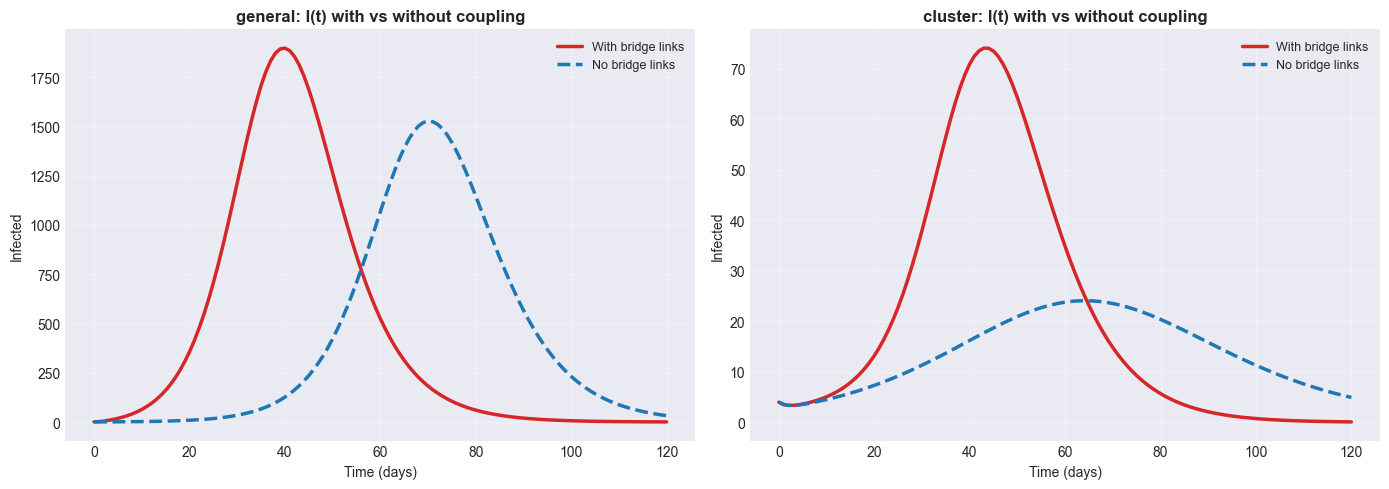

Bridge coupling effect summary:
population  peak_I_with_bridge  peak_I_no_bridge  cum_inf_with_bridge  cum_inf_no_bridge
   general             1896.85           1526.66              9321.04            8770.52
   cluster               74.07             24.08               419.40             284.85


In [6]:
C_no_bridge = C.copy()
for i in range(len(names)):
    for j in range(len(names)):
        if i != j:
            C_no_bridge[i, j] = 0.0

model_no_bridge = StructuredEpidemicModel(
    populations=scenario.populations,
    contact_matrix=C_no_bridge.tolist(),
    simulation=sim,
    intervention_plan=None,
)

traj_no_bridge = model_no_bridge.simulate()
df_no_bridge = trajectory_to_df(traj_no_bridge)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for k, p in enumerate(names):
    d_base = df[df['population'] == p]
    d_iso = df_no_bridge[df_no_bridge['population'] == p]

    ax = axes[k]
    ax.plot(d_base['time'], d_base['I'], label='With bridge links', linewidth=2.5, color='#d62728')
    ax.plot(d_iso['time'], d_iso['I'], label='No bridge links', linewidth=2.5, linestyle='--', color='#1f77b4')
    ax.set_title(f"{p}: I(t) with vs without coupling", fontsize=12, fontweight='bold')
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Infected')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

rows = []
for p in names:
    b = df[df['population'] == p]
    z = df_no_bridge[df_no_bridge['population'] == p]
    rows.append({
        'population': p,
        'peak_I_with_bridge': b['I'].max(),
        'peak_I_no_bridge': z['I'].max(),
        'cum_inf_with_bridge': b['N'].iloc[-1] - b['S'].iloc[-1],
        'cum_inf_no_bridge': z['N'].iloc[-1] - z['S'].iloc[-1],
    })

print('Bridge coupling effect summary:')
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda x: f"{x:.2f}"))

## Effective Reproduction Matrix by Population

At full susceptibility, define next-generation entries:

$$K_{ij} = C_{ij} \cdot N_i \cdot \frac{1}{\gamma_j}$$

Interpretation: expected secondary infections in recipient population $i$ caused by one infectious individual in source population $j$.

In [7]:
pop_map = {p.name: p for p in scenario.populations}
N_vec = np.array([pop_map[n].size for n in names], dtype=float)
gamma_vec = np.array([1.0 / pop_map[n].disease.infectious_period for n in names], dtype=float)

K0 = np.zeros_like(C)
for i in range(len(names)):
    for j in range(len(names)):
        K0[i, j] = C[i, j] * N_vec[i] / gamma_vec[j]

eigvals = np.linalg.eigvals(K0)
R_global = float(np.max(np.real(eigvals)))
R_source = K0.sum(axis=0)
R_recipient = K0.sum(axis=1)

print('K0 (full susceptibility):')
print(pd.DataFrame(K0, index=names, columns=names).round(3))
print(f"\nGlobal structured R (spectral radius of K0): {R_global:.3f}")
print('\nSecondary infections generated by source population (column sums):')
for n, v in zip(names, R_source):
    print(f"  source={n:8s}: {v:.3f}")
print('\nSecondary infections received by recipient population (row sums):')
for n, v in zip(names, R_recipient):
    print(f"  recipient={n:8s}: {v:.3f}")

K0 (full susceptibility):
         general  cluster
general     2.40     10.8
cluster     0.03      1.5

Global structured R (spectral radius of K0): 2.676

Secondary infections generated by source population (column sums):
  source=general : 2.430
  source=cluster : 12.300

Secondary infections received by recipient population (row sums):
  recipient=general : 13.200
  recipient=cluster : 1.530


## Time-Varying Effective Reproduction Under Susceptible Depletion

As susceptibles decline, an effective next-generation matrix is:

$$K^{\text{eff}}_{ij}(t) = K_{ij} \cdot \frac{S_i(t)}{N_i}$$

This keeps contact structure fixed and isolates depletion effects by population.

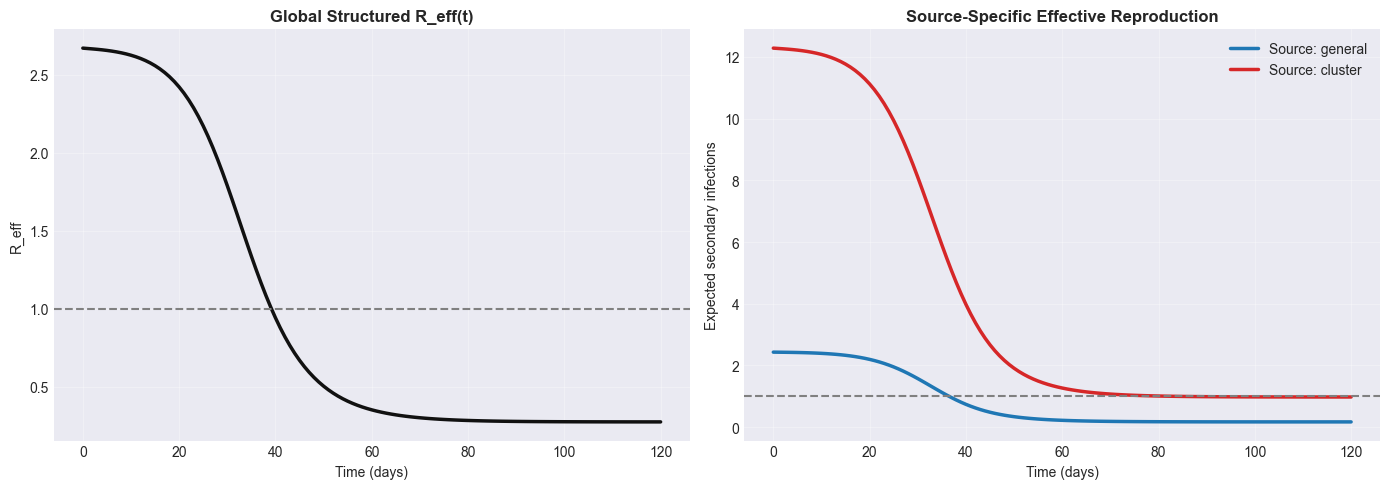

In [8]:
times = sorted(df['time'].unique())
records = []
for t in times:
    d_t = df[df['time'] == t].set_index('population')
    S_frac = np.array([d_t.loc[n, 'S'] / d_t.loc[n, 'N'] for n in names], dtype=float)

    K_eff = K0 * S_frac[:, None]
    R_eff_global = float(np.max(np.real(np.linalg.eigvals(K_eff))))
    src = K_eff.sum(axis=0)

    records.append({
        'time': t,
        'R_eff_global': R_eff_global,
        'R_eff_source_general': src[0],
        'R_eff_source_cluster': src[1],
    })

df_reff = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(df_reff['time'], df_reff['R_eff_global'], linewidth=2.5, color='#111111')
ax.axhline(1.0, linestyle='--', color='gray', linewidth=1.5)
ax.set_title('Global Structured R_eff(t)', fontsize=12, fontweight='bold')
ax.set_xlabel('Time (days)')
ax.set_ylabel('R_eff')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(df_reff['time'], df_reff['R_eff_source_general'], linewidth=2.5, label='Source: general', color='#1f77b4')
ax.plot(df_reff['time'], df_reff['R_eff_source_cluster'], linewidth=2.5, label='Source: cluster', color='#d62728')
ax.axhline(1.0, linestyle='--', color='gray', linewidth=1.5)
ax.set_title('Source-Specific Effective Reproduction', fontsize=12, fontweight='bold')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Expected secondary infections')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary and Takeaways

1. **Population structure changes trajectories even without interventions**. The cluster can amplify quickly due to stronger within-group transmission while also seeding the general population through bridge links.

2. **Bridge links matter nonlinearly**. Removing off-diagonal coupling changes both peak timing and burden, even though all within-group parameters are unchanged.

3. **Effective reproduction is matrix-valued in structured models**. A single scalar can hide who is generating transmission and who is receiving it.

4. **Susceptible depletion is population-specific**. Different groups can move below replacement at different times, producing composite epidemic patterns at system level.

This sets up intervention analysis naturally: interventions become targeted changes to specific matrix entries and can be evaluated by their group-level and system-level effects.

## Appendix: Structured SEIR Equations

For each population $i$:

$$\frac{dS_i}{dt} = -S_i \sum_j C_{ij} I_j$$
$$\frac{dE_i}{dt} = S_i \sum_j C_{ij} I_j - \sigma_i E_i$$
$$\frac{dI_i}{dt} = \sigma_i E_i - \gamma_i I_i$$
$$\frac{dR_i}{dt} = \gamma_i I_i$$

where $C_{ij}$ is transmission contribution from source group $j$ into recipient group $i$.

In this notebook, we keep $C$ fixed in time (no interventions), so all differences arise from structure and depletion alone.